# Deep CNN

In [1]:
!pip install wandb -q

In [2]:
from kaggle_secrets import UserSecretsClient
import wandb

secrets = UserSecretsClient()
wandb.login(key=secrets.get_secret("WANDB_API_KEY"))

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gdzag22 (gdzag22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Data Loading

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

df = pd.read_csv('/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/icml_face_data.csv')
df.columns = df.columns.str.strip()

train_df = df[df['Usage'] == 'Training'].reset_index(drop=True)
val_df = df[df['Usage'] == 'PublicTest'].reset_index(drop=True)
test_df = df[df['Usage'] == 'PrivateTest'].reset_index(drop=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Device:", device)

Train: 28709 Val: 3589 Test: 3589
Device: cuda


In [6]:
class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        pixels = np.array(self.dataframe.iloc[idx]['pixels'].split(),
                          dtype=np.uint8).reshape(48, 48)
        image = Image.fromarray(pixels)
        if self.transform:
            image= self.transform(image)
        label = int(self.dataframe.iloc[idx]['emotion'])
        return image, label

augmented_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(48, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = FERDataset(train_df, transform=augmented_transform)
val_dataset = FERDataset(val_df, transform=val_transform)
test_dataset = FERDataset(test_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset,  batch_size=64, shuffle=False)
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
print("One batch shape:", next(iter(train_loader))[0].shape)

One batch shape: torch.Size([64, 1, 48, 48])


# Forward Sanity Check

In [7]:
expected_loss = np.log(7)
print(f"Expected initial loss: {expected_loss:.4f}")

test_model = nn.Sequential(
    nn.Conv2d(1, 32, 3, padding=1),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(32 * 48 * 48, 7)
).to(device)

images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    out = test_model(images)
    loss = nn.CrossEntropyLoss()(out, labels)

print(f"Actual initial loss:   {loss.item():.4f}")

Expected initial loss: 1.9459
Actual initial loss:   1.9596


In [ ]:
# backward
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

small_images = images[:10]
small_labels = labels[:10]

optimizer_test = torch.optim.Adam(test_model.parameters(), lr=0.01)
losses = []
for step in range(200):
    optimizer_test.zero_grad()
    out = test_model(small_images)
    loss = nn.CrossEntropyLoss()(out, small_labels)
    loss.backward()
    optimizer_test.step()
    losses.append(loss.item())

print(f"Loss after overfitting 10 samples: {losses[-1]:.4f}")

# Training Utilities

In [8]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total


def run_experiment(model, run_name, epochs=40, lr=0.001, weight_decay=1e-3):
    run = wandb.init(
        project="facial_expression_recognition",
        group="DeepCNN",
        name=run_name,
        config={
            'epochs': epochs,
            'lr': lr,
            'optimizer': 'Adam',
            'weight_decay': weight_decay,
            'scheduler': 'CosineAnnealing',
            'augmentation': True,
            'batch_size': 64
        }
    )

    criterion = nn.CrossEntropyLoss()
    optimizer= torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_accs, val_accs, train_losses, val_losses = [], [], [], []

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss,val_acc = evaluate(model, val_loader, criterion)
        scheduler.step()
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'lr': optimizer.param_groups[0]['lr']
        })

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    np.save(f'/kaggle/working/{run_name}.npy', [train_accs, val_accs, train_losses, val_losses])
    wandb.finish()
    return train_accs, val_accs, train_losses, val_losses

# Training

### Deeper CNN Baseline

In [9]:
class DeepCNN_v1(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.bn1= nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)
        self.drop = nn.Dropout(0.4)
        self.fc1 = nn.Linear(256 * 3 * 3, 512)
        self.fc2 = nn.Linear(512, 7)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x)))) 
        x = self.pool(torch.relu(self.bn2(self.conv2(x)))) 
        x= self.pool(torch.relu(self.bn3(self.conv3(x))))  
        x = self.pool(torch.relu(self.bn4(self.conv4(x)))) 
        x = x.view(x.size(0), -1)
        x = self.drop(torch.relu(self.fc1(x)))
        return self.fc2(x)

model_v1 = DeepCNN_v1().to(device)
v1_train_accs, v1_val_accs, v1_train_losses , v1_val_losses = run_experiment(
    model_v1, 'DeepCNN_v1_4conv', epochs=40
)

Epoch 1/40 | Train Acc: 0.2827 | Val Acc: 0.4043 | LR: 0.000998
Epoch 2/40 | Train Acc: 0.4095 | Val Acc: 0.4756 | LR: 0.000994
Epoch 3/40 | Train Acc: 0.4606 | Val Acc: 0.5015 | LR: 0.000986
Epoch 4/40 | Train Acc: 0.4915 | Val Acc: 0.5065 | LR: 0.000976
Epoch 5/40 | Train Acc: 0.5053 | Val Acc: 0.4586 | LR: 0.000962
Epoch 6/40 | Train Acc: 0.5224 | Val Acc: 0.5241 | LR: 0.000946
Epoch 7/40 | Train Acc: 0.5368 | Val Acc: 0.5500 | LR: 0.000926
Epoch 8/40 | Train Acc: 0.5492 | Val Acc: 0.5578 | LR: 0.000905
Epoch 9/40 | Train Acc: 0.5541 | Val Acc: 0.5592 | LR: 0.000880
Epoch 10/40 | Train Acc: 0.5638 | Val Acc: 0.5701 | LR: 0.000854
Epoch 11/40 | Train Acc: 0.5722 | Val Acc: 0.5826 | LR: 0.000825
Epoch 12/40 | Train Acc: 0.5793 | Val Acc: 0.5896 | LR: 0.000794
Epoch 13/40 | Train Acc: 0.5867 | Val Acc: 0.5893 | LR: 0.000761
Epoch 14/40 | Train Acc: 0.5903 | Val Acc: 0.5868 | LR: 0.000727
Epoch 15/40 | Train Acc: 0.5998 | Val Acc: 0.5745 | LR: 0.000691
Epoch 16/40 | Train Acc: 0.5999 | 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▃▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇███████████
train_loss,█▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▄▃▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████████████
val_loss,█▆▅▅▇▄▃▄▃▃▃▃▃▂▃▂▂▂▂▂▂▂▁▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
lr,0
train_acc,0.70142
train_loss,0.81303
val_acc,0.65534


### Wider Filters

In [10]:
class DeepCNN_v2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)

        self.pool = nn.MaxPool2d(2, 2)
        self.drop = nn.Dropout(0.4)
        self.fc1 = nn.Linear(512 * 3* 3, 512)
        self.fc2 = nn.Linear(512, 7)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = self.pool(torch.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = self.drop(torch.relu(self.fc1(x)))
        return self.fc2(x)

model_v2 = DeepCNN_v2().to(device)
v2_train_accs, v2_val_accs, v2_train_losses, v2_val_losses = run_experiment(
    model_v2, 'DeepCNN_v2_wider', epochs=40
)

Epoch 1/40 | Train Acc: 0.2563 | Val Acc: 0.3441 | LR: 0.000998
Epoch 2/40 | Train Acc: 0.3767 | Val Acc: 0.4230 | LR: 0.000994
Epoch 3/40 | Train Acc: 0.4289 | Val Acc: 0.4533 | LR: 0.000986
Epoch 4/40 | Train Acc: 0.4630 | Val Acc: 0.4804 | LR: 0.000976
Epoch 5/40 | Train Acc: 0.4844 | Val Acc: 0.5258 | LR: 0.000962
Epoch 6/40 | Train Acc: 0.5032 | Val Acc: 0.5319 | LR: 0.000946
Epoch 7/40 | Train Acc: 0.5198 | Val Acc: 0.5500 | LR: 0.000926
Epoch 8/40 | Train Acc: 0.5386 | Val Acc: 0.5626 | LR: 0.000905
Epoch 9/40 | Train Acc: 0.5517 | Val Acc: 0.5531 | LR: 0.000880
Epoch 10/40 | Train Acc: 0.5635 | Val Acc: 0.5670 | LR: 0.000854
Epoch 11/40 | Train Acc: 0.5718 | Val Acc: 0.5717 | LR: 0.000825
Epoch 12/40 | Train Acc: 0.5799 | Val Acc: 0.5754 | LR: 0.000794
Epoch 13/40 | Train Acc: 0.5850 | Val Acc: 0.5918 | LR: 0.000761
Epoch 14/40 | Train Acc: 0.5936 | Val Acc: 0.5929 | LR: 0.000727
Epoch 15/40 | Train Acc: 0.6007 | Val Acc: 0.5832 | LR: 0.000691
Epoch 16/40 | Train Acc: 0.6031 | 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▃▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇████████████
train_loss,█▆▅▅▅▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▃▄▅▅▆▆▆▆▆▆▇▇▆▇▇▇▇▇▇▇▇▇█▇▇█████████████
val_loss,█▆▆▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
lr,0
train_acc,0.70473
train_loss,0.79975
val_acc,0.65032


### Residual Connections

In [11]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x = x +residual 
        return torch.relu(x)


class DeepCNN_v3_Residual(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(64)

        self.res1 = ResidualBlock(64)
        self.conv2 = nn.Conv2d(64, 128,  kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)

        self.res2 = ResidualBlock(128)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)
        self.drop = nn.Dropout(0.4)
        self.fc1 = nn.Linear(256 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, 7)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))  
        x = self.res1(x)
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))  
        x = self.res2(x)
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))  
        x = x.view(x.size(0), -1)
        x = self.drop(torch.relu(self.fc1(x)))
        return self.fc2(x)

model_v3 = DeepCNN_v3_Residual().to(device)
v3_train_accs, v3_val_accs, v3_train_losses, v3_val_losses = run_experiment(
    model_v3, 'DeepCNN_v3_residual', epochs=40
)

Epoch 1/40 | Train Acc: 0.2442 | Val Acc: 0.2497 | LR: 0.000998
Epoch 2/40 | Train Acc: 0.2865 | Val Acc: 0.3553 | LR: 0.000994
Epoch 3/40 | Train Acc: 0.3760 | Val Acc: 0.4274 | LR: 0.000986
Epoch 4/40 | Train Acc: 0.4203 | Val Acc: 0.4533 | LR: 0.000976
Epoch 5/40 | Train Acc: 0.4519 | Val Acc: 0.4940 | LR: 0.000962
Epoch 6/40 | Train Acc: 0.4743 | Val Acc: 0.5049 | LR: 0.000946
Epoch 7/40 | Train Acc: 0.5019 | Val Acc: 0.5219 | LR: 0.000926
Epoch 8/40 | Train Acc: 0.5227 | Val Acc: 0.5536 | LR: 0.000905
Epoch 9/40 | Train Acc: 0.5395 | Val Acc: 0.5425 | LR: 0.000880
Epoch 10/40 | Train Acc: 0.5523 | Val Acc: 0.5573 | LR: 0.000854
Epoch 11/40 | Train Acc: 0.5666 | Val Acc: 0.5313 | LR: 0.000825
Epoch 12/40 | Train Acc: 0.5765 | Val Acc: 0.5598 | LR: 0.000794
Epoch 13/40 | Train Acc: 0.5825 | Val Acc: 0.5754 | LR: 0.000761
Epoch 14/40 | Train Acc: 0.5887 | Val Acc: 0.5756 | LR: 0.000727
Epoch 15/40 | Train Acc: 0.5962 | Val Acc: 0.5826 | LR: 0.000691
Epoch 16/40 | Train Acc: 0.6028 | 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▂▃▄▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
train_loss,█▇▆▅▅▅▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█▇▇████████████████
val_loss,█▆▅▅▄▃▃▃▃▃▄▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
lr,0
train_acc,0.7149
train_loss,0.76912
val_acc,0.65339


### Deeper Residual Network

In [12]:
class DeepCNN_v4(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(64)
        self.res1 = ResidualBlock(64)
        self.res2 = ResidualBlock(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.res3 = ResidualBlock(128)
        self.res4 = ResidualBlock(128)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.res5 = ResidualBlock(256)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        self.pool = nn.MaxPool2d(2, 2)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(0.5)
        self.fc = nn.Linear(512,7)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.res1(x)
        x = self.res2(x)
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.res3(x)
        x = self.res4(x)
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = self.res5(x)
        x = torch.relu(self.bn4(self.conv4(x)))
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.drop(x)
        return self.fc(x)

model_v4 = DeepCNN_v4().to(device)
v4_train_accs, v4_val_accs, v4_train_losses, v4_val_losses = run_experiment(
    model_v4, 'DeepCNN_v4_deep_residual', epochs=40
)

Epoch 1/40 | Train Acc: 0.3552 | Val Acc: 0.4121 | LR: 0.000998
Epoch 2/40 | Train Acc: 0.4656 | Val Acc: 0.4748 | LR: 0.000994
Epoch 3/40 | Train Acc: 0.4962 | Val Acc: 0.5026 | LR: 0.000986
Epoch 4/40 | Train Acc: 0.5187 | Val Acc: 0.5088 | LR: 0.000976
Epoch 5/40 | Train Acc: 0.5292 | Val Acc: 0.5274 | LR: 0.000962
Epoch 6/40 | Train Acc: 0.5458 | Val Acc: 0.5475 | LR: 0.000946
Epoch 7/40 | Train Acc: 0.5582 | Val Acc: 0.5113 | LR: 0.000926
Epoch 8/40 | Train Acc: 0.5655 | Val Acc: 0.5701 | LR: 0.000905
Epoch 9/40 | Train Acc: 0.5746 | Val Acc: 0.5676 | LR: 0.000880
Epoch 10/40 | Train Acc: 0.5836 | Val Acc: 0.5715 | LR: 0.000854
Epoch 11/40 | Train Acc: 0.5863 | Val Acc: 0.5804 | LR: 0.000825
Epoch 12/40 | Train Acc: 0.5942 | Val Acc: 0.5910 | LR: 0.000794
Epoch 13/40 | Train Acc: 0.6009 | Val Acc: 0.6219 | LR: 0.000761
Epoch 14/40 | Train Acc: 0.6059 | Val Acc: 0.5949 | LR: 0.000727
Epoch 15/40 | Train Acc: 0.6126 | Val Acc: 0.6024 | LR: 0.000691
Epoch 16/40 | Train Acc: 0.6191 | 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█████████
train_loss,█▆▆▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▄▄▅▄▅▅▅▆▆▇▆▆▆▆▆▇▇▇▇▇▇█▇██████████████
val_loss,█▇▅▅▅▅▆▄▄▄▃▃▂▃▃▂▂▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
lr,0
train_acc,0.73022
train_loss,0.73499
val_acc,0.65979


### Hyperparameter tuning on best architecture

In [13]:
configs = [
    {'dropout': 0.3, 'lr': 0.001, 'name': 'DeepCNN_v4_dropout03'},
    {'dropout': 0.5, 'lr': 0.0005, 'name': 'DeepCNN_v4_lr0005'},
    {'dropout': 0.4, 'lr': 0.001, 'weight_decay': 1e-4, 'name': 'DeepCNN_v4_wd1e4'},
]

for cfg in configs:
    class DeepCNN_v4_cfg(nn.Module):
        def __init__(self, dropout):
            super().__init__()
            self.conv1 = nn.Conv2d(1, 64, kernel_size=5, padding=2)
            self.bn1 = nn.BatchNorm2d(64)
            self.res1 = ResidualBlock(64)
            self.res2 = ResidualBlock(64)
            self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
            self.bn2 = nn.BatchNorm2d(128)
            self.res3 = ResidualBlock(128)
            self.res4 = ResidualBlock(128)
            self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
            self.bn3 = nn.BatchNorm2d(256)
            self.res5 = ResidualBlock(256)
            self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
            self.bn4 = nn.BatchNorm2d(512)
            self.pool = nn.MaxPool2d(2, 2)
            self.gap = nn.AdaptiveAvgPool2d(1)
            self.drop = nn.Dropout(dropout)
            self.fc = nn.Linear(512, 7)

        def forward(self, x):
            x = self.pool(torch.relu(self.bn1(self.conv1(x))))
            x = self.res1(x)
            x = self.res2(x)
            x = self.pool(torch.relu(self.bn2(self.conv2(x))))
            x = self.res3(x)
            x = self.res4(x)
            x = self.pool(torch.relu(self.bn3(self.conv3(x))))
            x = self.res5(x)
            x = torch.relu(self.bn4(self.conv4(x)))
            x = self.gap(x)
            x = x.view(x.size(0), -1)
            x = self.drop(x)
            return self.fc(x)

    model = DeepCNN_v4_cfg(dropout=cfg['dropout']).to(device)
    wd = cfg.get('weight_decay', 1e-3)
    run_experiment(model, cfg['name'], epochs=40, lr=cfg['lr'], weight_decay=wd)

Epoch 1/40 | Train Acc: 0.3560 | Val Acc: 0.4603 | LR: 0.000998
Epoch 2/40 | Train Acc: 0.4676 | Val Acc: 0.4687 | LR: 0.000994
Epoch 3/40 | Train Acc: 0.4961 | Val Acc: 0.4831 | LR: 0.000986
Epoch 4/40 | Train Acc: 0.5149 | Val Acc: 0.3940 | LR: 0.000976
Epoch 5/40 | Train Acc: 0.5347 | Val Acc: 0.5121 | LR: 0.000962
Epoch 6/40 | Train Acc: 0.5493 | Val Acc: 0.5442 | LR: 0.000946
Epoch 7/40 | Train Acc: 0.5553 | Val Acc: 0.5171 | LR: 0.000926
Epoch 8/40 | Train Acc: 0.5677 | Val Acc: 0.5578 | LR: 0.000905
Epoch 9/40 | Train Acc: 0.5765 | Val Acc: 0.5676 | LR: 0.000880
Epoch 10/40 | Train Acc: 0.5849 | Val Acc: 0.5765 | LR: 0.000854
Epoch 11/40 | Train Acc: 0.5897 | Val Acc: 0.5656 | LR: 0.000825
Epoch 12/40 | Train Acc: 0.5963 | Val Acc: 0.5918 | LR: 0.000794
Epoch 13/40 | Train Acc: 0.6035 | Val Acc: 0.6080 | LR: 0.000761
Epoch 14/40 | Train Acc: 0.6096 | Val Acc: 0.5957 | LR: 0.000727
Epoch 15/40 | Train Acc: 0.6145 | Val Acc: 0.5918 | LR: 0.000691
Epoch 16/40 | Train Acc: 0.6210 | 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇████████
train_loss,█▆▆▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▃▃▃▁▄▅▄▅▅▆▅▆▇▆▆▆▇▇▇▇▇▇▇▇▇█▇█████████████
val_loss,▆▆▆█▅▄▅▄▃▃▃▃▂▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
lr,0
train_acc,0.73392
train_loss,0.71931
val_acc,0.66509


Epoch 1/40 | Train Acc: 0.3710 | Val Acc: 0.4589 | LR: 0.000499
Epoch 2/40 | Train Acc: 0.4898 | Val Acc: 0.5038 | LR: 0.000497
Epoch 3/40 | Train Acc: 0.5223 | Val Acc: 0.5096 | LR: 0.000493
Epoch 4/40 | Train Acc: 0.5402 | Val Acc: 0.5330 | LR: 0.000488
Epoch 5/40 | Train Acc: 0.5530 | Val Acc: 0.5475 | LR: 0.000481
Epoch 6/40 | Train Acc: 0.5658 | Val Acc: 0.5709 | LR: 0.000473
Epoch 7/40 | Train Acc: 0.5734 | Val Acc: 0.5584 | LR: 0.000463
Epoch 8/40 | Train Acc: 0.5797 | Val Acc: 0.5653 | LR: 0.000452
Epoch 9/40 | Train Acc: 0.5930 | Val Acc: 0.5832 | LR: 0.000440
Epoch 10/40 | Train Acc: 0.5996 | Val Acc: 0.5907 | LR: 0.000427
Epoch 11/40 | Train Acc: 0.6049 | Val Acc: 0.5698 | LR: 0.000412
Epoch 12/40 | Train Acc: 0.6120 | Val Acc: 0.5982 | LR: 0.000397
Epoch 13/40 | Train Acc: 0.6179 | Val Acc: 0.6080 | LR: 0.000381
Epoch 14/40 | Train Acc: 0.6240 | Val Acc: 0.5949 | LR: 0.000363
Epoch 15/40 | Train Acc: 0.6321 | Val Acc: 0.6138 | LR: 0.000346
Epoch 16/40 | Train Acc: 0.6369 | 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇█████████
train_loss,█▆▆▅▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▂▃▃▄▅▄▄▅▅▅▅▆▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████
val_loss,█▇▇▅▆▄▅▅▄▃▅▄▃▃▃▃▄▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
lr,0
train_acc,0.77491
train_loss,0.61981
val_acc,0.6715


Epoch 1/40 | Train Acc: 0.3525 | Val Acc: 0.4494 | LR: 0.000998
Epoch 2/40 | Train Acc: 0.4835 | Val Acc: 0.4592 | LR: 0.000994
Epoch 3/40 | Train Acc: 0.5128 | Val Acc: 0.4823 | LR: 0.000986
Epoch 4/40 | Train Acc: 0.5393 | Val Acc: 0.5386 | LR: 0.000976
Epoch 5/40 | Train Acc: 0.5572 | Val Acc: 0.5469 | LR: 0.000962
Epoch 6/40 | Train Acc: 0.5735 | Val Acc: 0.5587 | LR: 0.000946
Epoch 7/40 | Train Acc: 0.5802 | Val Acc: 0.5756 | LR: 0.000926
Epoch 8/40 | Train Acc: 0.5910 | Val Acc: 0.5954 | LR: 0.000905
Epoch 9/40 | Train Acc: 0.6042 | Val Acc: 0.5968 | LR: 0.000880
Epoch 10/40 | Train Acc: 0.6075 | Val Acc: 0.5907 | LR: 0.000854
Epoch 11/40 | Train Acc: 0.6185 | Val Acc: 0.6116 | LR: 0.000825
Epoch 12/40 | Train Acc: 0.6214 | Val Acc: 0.6055 | LR: 0.000794
Epoch 13/40 | Train Acc: 0.6312 | Val Acc: 0.6046 | LR: 0.000761
Epoch 14/40 | Train Acc: 0.6363 | Val Acc: 0.6264 | LR: 0.000727
Epoch 15/40 | Train Acc: 0.6465 | Val Acc: 0.6342 | LR: 0.000691
Epoch 16/40 | Train Acc: 0.6537 | 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▃▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇█████████
train_loss,█▆▆▅▅▅▅▅▄▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▁▂▄▄▄▅▅▅▅▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇██▇████████████
val_loss,█▇▇▅▄▄▄▃▃▃▃▃▃▂▂▂▁▂▁▁▂▁▁▁▁▁▂▁▁▁▁▂▂▂▂▂▂▂▂▂
epoch,40
lr,0
train_acc,0.81034
train_loss,0.51702
val_acc,0.68292


### Label Smoothing

In [14]:
model = DeepCNN_v4_cfg(dropout=0.4).to(device)
criterion_ls = nn.CrossEntropyLoss(label_smoothing=0.1)

run = wandb.init(
    project="facial_expression_recognition",
    group="DeepCNN",
    name="DeepCNN_v4_label_smoothing",
    config={
        'epochs': 40,
        'lr': 0.001,
        'optimizer': 'Adam',
        'weight_decay': 1e-4,
        'scheduler': 'CosineAnnealing',
        'label_smoothing': 0.1,
        'augmentation': True
    }
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

train_accs, val_accs,train_losses, val_losses = [], [], [], []

for epoch in range(40):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion_ls)
    val_loss, val_acc =  evaluate(model, val_loader, criterion_ls)
    scheduler.step()

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'lr': optimizer.param_groups[0]['lr']
    })

    print(f"Epoch {epoch+1}/40 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

np.save('/kaggle/working/DeepCNN_v4_label_smoothing.npy', [train_accs, val_accs, train_losses, val_losses])
wandb.finish()

Epoch 1/40 | Train Acc: 0.3458 | Val Acc: 0.4021
Epoch 2/40 | Train Acc: 0.4807 | Val Acc: 0.4851
Epoch 3/40 | Train Acc: 0.5166 | Val Acc: 0.4993
Epoch 4/40 | Train Acc: 0.5445 | Val Acc: 0.5010
Epoch 5/40 | Train Acc: 0.5587 | Val Acc: 0.5163
Epoch 6/40 | Train Acc: 0.5721 | Val Acc: 0.5486
Epoch 7/40 | Train Acc: 0.5822 | Val Acc: 0.5946
Epoch 8/40 | Train Acc: 0.5873 | Val Acc: 0.5704
Epoch 9/40 | Train Acc: 0.6023 | Val Acc: 0.6002
Epoch 10/40 | Train Acc: 0.6099 | Val Acc: 0.6004
Epoch 11/40 | Train Acc: 0.6161 | Val Acc: 0.5762
Epoch 12/40 | Train Acc: 0.6248 | Val Acc: 0.6024
Epoch 13/40 | Train Acc: 0.6327 | Val Acc: 0.6152
Epoch 14/40 | Train Acc: 0.6385 | Val Acc: 0.6177
Epoch 15/40 | Train Acc: 0.6502 | Val Acc: 0.6278
Epoch 16/40 | Train Acc: 0.6538 | Val Acc: 0.6303
Epoch 17/40 | Train Acc: 0.6594 | Val Acc: 0.6177
Epoch 18/40 | Train Acc: 0.6668 | Val Acc: 0.6333
Epoch 19/40 | Train Acc: 0.6773 | Val Acc: 0.6445
Epoch 20/40 | Train Acc: 0.6772 | Val Acc: 0.6500
Epoch 21/

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇█████████
train_loss,█▆▆▅▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▃▃▃▄▅▆▅▆▆▅▆▆▆▇▇▆▇▇▇▇▇▇▇▇▇▇█████████████
val_loss,█▅▅▆▄▃▃▃▂▃▃▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
lr,0
train_acc,0.8103
train_loss,0.85556
val_acc,0.68348


# Analysis

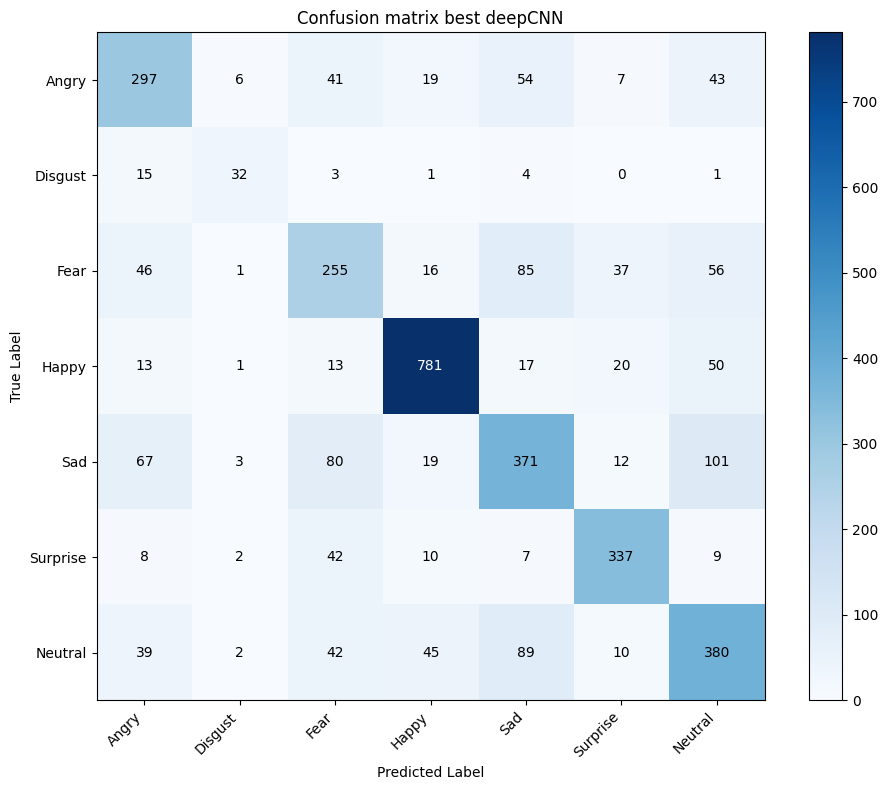

In [15]:
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

best_model = model
best_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = best_model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)
ax.set_xticks(range(7))
ax.set_yticks(range(7))
ax.set_xticklabels(emotion_labels, rotation=45, ha='right')
ax.set_yticklabels(emotion_labels)

for i in range(7):
    for j in range(7):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_title('Confusion matrix best deepCNN')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/kaggle/working/deepcnn_confusion_matrix.png', dpi=150)
plt.show()

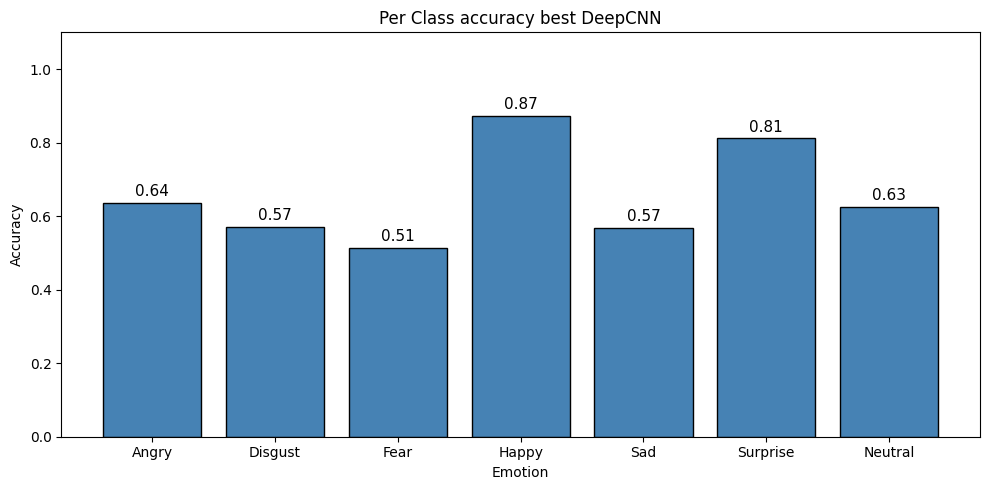

In [16]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(emotion_labels, per_class_acc, color='steelblue', edgecolor='black')

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.2f}', ha='center', va='bottom', fontsize=11)

ax.set_title('Per Class accuracy best DeepCNN')
ax.set_xlabel('Emotion')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('/kaggle/working/deepcnn_per_class_accuracy.png', dpi=150)
plt.show()